In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("PyTorch version :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())
print("Device :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version : 2.10.0+cu128
GPU disponible : True
Device : Tesla T4


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Taille du dataset :", df.shape)
print("\nAperçu des premières lignes :")
df.head()

Taille du dataset : (1599, 12)

Aperçu des premières lignes :


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
print("=== Informations générales ===")
print(df.info())

print("\n=== Statistiques descriptives ===")
print(df.describe())

print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())

print("\n=== Distribution de la cible (quality) ===")
print(df['quality'].value_counts())

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

=== Statistiques descriptives ===
       fixed acidity  volatile acidity  citric acid  re

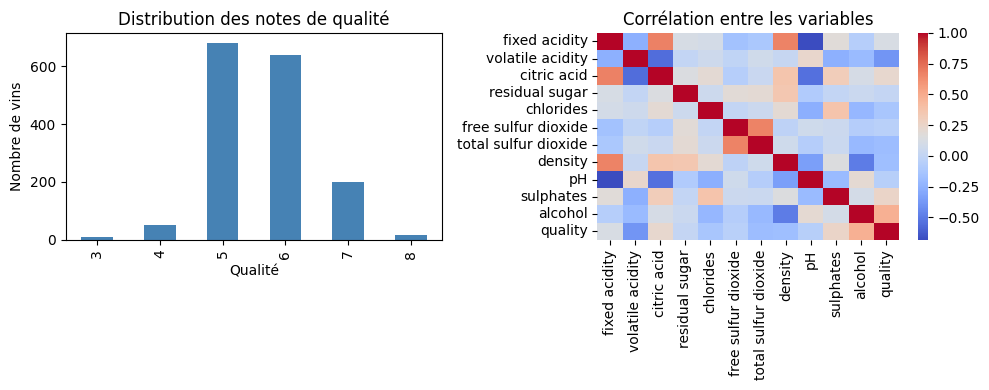

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Distribution des notes de qualité")
plt.xlabel("Qualité")
plt.ylabel("Nombre de vins")

plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Corrélation entre les variables")

plt.tight_layout()
plt.show()

### **Transformation de la note en : 0 = mauvais (qualité <= 5), 1 = bon (qualité >= 6)**

In [ ]:
df['target'] = (df['quality'] >= 6).astype(int)

print("Distribution de la cible binaire :")
print(df['target'].value_counts())
print(f"\n0 = mauvais vin : {(df['target']==0).sum()} vins")
print(f"1 = bon vin    : {(df['target']==1).sum()} vins")

Distribution de la cible binaire :
target
1    855
0    744
Name: count, dtype: int64

0 = mauvais vin : 744 vins
1 = bon vin    : 855 vins


In [ ]:
X = df.drop(columns=['quality', 'target']).values

y = df['target'].values

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)

Forme de X : (1599, 11)
Forme de y : (1599,)


**Entrainement, Valisation et test**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train      : {X_train.shape[0]} exemples")
print(f"Validation : {X_val.shape[0]} exemples")
print(f"Test       : {X_test.shape[0]} exemples")

Train      : 1119 exemples
Validation : 240 exemples
Test       : 240 exemples


In [ ]:
scaler = StandardScaler()

# On apprend la normalisation UNIQUEMENT sur le train
X_train = scaler.fit_transform(X_train)

# On applique la même normalisation sur val et test
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Moyenne après normalisation (train) :", X_train.mean(axis=0).round(2))
print("Écart-type après normalisation (train) :", X_train.std(axis=0).round(2))

Moyenne après normalisation (train) : [-0.  0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
Écart-type après normalisation (train) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Convertion Pytorch bach ikhedem ses tenseurs**

In [ ]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)

X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

print("Type X_train_t :", X_train_t.dtype)
print("Type y_train_t :", y_train_t.dtype)

Type X_train_t : torch.float32
Type y_train_t : torch.int64


In [ ]:
import torch.nn as nn

model_sequential = nn.Sequential(
    nn.Linear(11, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 2)
)

print(model_sequential)
print("\nNombre total de paramètres :", sum(p.numel() for p in model_sequential.parameters()))

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=32, out_features=2, bias=True)
)

Nombre total de paramètres : 2914


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))   # couche 1 + activation
        x = self.dropout(x)          # dropout
        x = self.relu(self.fc2(x))   # couche 2 + activation
        x = self.fc3(x)              # couche de sortie
        return x

model_custom = MLP(input_size=11, hidden1=64, hidden2=32, output_size=2)
print(model_custom)

MLP(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
print("=== Paramètres du modèle (named_parameters) ===")
for name, param in model_custom.named_parameters():
    print(f"{name} | forme : {param.shape} | nb params : {param.numel()}")

print("\n=== state_dict (extrait) ===")
for key in list(model_custom.state_dict().keys()):
    print(key, "→", model_custom.state_dict()[key].shape)

=== Paramètres du modèle (named_parameters) ===
fc1.weight | forme : torch.Size([64, 11]) | nb params : 704
fc1.bias | forme : torch.Size([64]) | nb params : 64
fc2.weight | forme : torch.Size([32, 64]) | nb params : 2048
fc2.bias | forme : torch.Size([32]) | nb params : 32
fc3.weight | forme : torch.Size([2, 32]) | nb params : 64
fc3.bias | forme : torch.Size([2]) | nb params : 2

=== state_dict (extrait) ===
fc1.weight → torch.Size([64, 11])
fc1.bias → torch.Size([64])
fc2.weight → torch.Size([32, 64])
fc2.bias → torch.Size([32])
fc3.weight → torch.Size([2, 32])
fc3.bias → torch.Size([2])


In [ ]:
def init_gaussian(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.normal_(layer.weight, mean=0, std=0.01)
            nn.init.zeros_(layer.bias)

def init_constant(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.constant_(layer.weight, 0.1)
            nn.init.zeros_(layer.bias)

def init_xavier(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

model = MLP(11, 64, 32, 2)
init_xavier(model)
print("Modèle initialisé avec Xavier")

Modèle initialisé avec Xavier


In [ ]:
# Device (GPU si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

# Déplacer le modèle sur le device
model = model.to(device)

# Fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Prêt à entraîner ✅")

Device utilisé : cuda
Prêt à entraîner ✅


In [ ]:
num_epochs = 100
train_losses, val_losses, val_accuracies = [], [], []

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)

best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_pred = torch.argmax(val_outputs, dim=1)
        val_acc = accuracy_score(y_val_t.cpu(), val_pred.cpu())
    val_losses.append(val_loss.item())
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    if (epoch+1) % 10 == 0:
        print(f"Époque {epoch+1}/100 | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}")

Époque 10/100 | Train Loss: 0.7129 | Val Loss: 0.6876 | Val Acc: 0.5667
Époque 20/100 | Train Loss: 0.6277 | Val Loss: 0.6040 | Val Acc: 0.6833
Époque 30/100 | Train Loss: 0.5823 | Val Loss: 0.5767 | Val Acc: 0.6875
Époque 40/100 | Train Loss: 0.5655 | Val Loss: 0.5662 | Val Acc: 0.6917
Époque 50/100 | Train Loss: 0.5285 | Val Loss: 0.5645 | Val Acc: 0.6792
Époque 60/100 | Train Loss: 0.5236 | Val Loss: 0.5627 | Val Acc: 0.6833
Époque 70/100 | Train Loss: 0.5179 | Val Loss: 0.5617 | Val Acc: 0.6958
Époque 80/100 | Train Loss: 0.5082 | Val Loss: 0.5612 | Val Acc: 0.7000
Époque 90/100 | Train Loss: 0.5168 | Val Loss: 0.5604 | Val Acc: 0.6917
Époque 100/100 | Train Loss: 0.5039 | Val Loss: 0.5577 | Val Acc: 0.7042


**Visualisation entrainement**

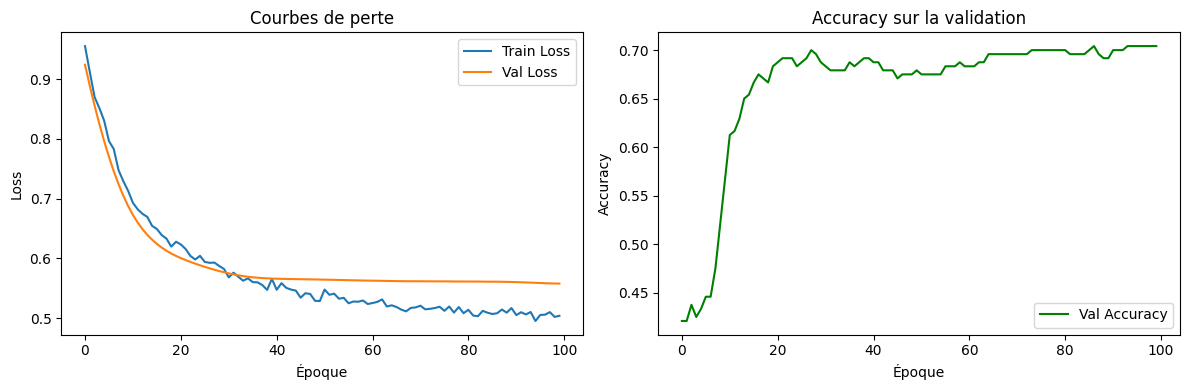

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Courbes de perte")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', color='green')
plt.title("Accuracy sur la validation")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Eval Finale**

=== Résultats sur le jeu de test ===
Accuracy  : 0.7667
Precision : 0.7937
Recall    : 0.7692
F1-Score  : 0.7812


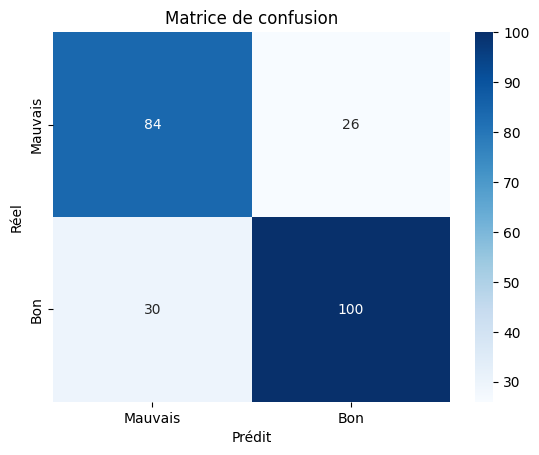

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

X_test_t = X_test_t.to(device)

with torch.no_grad():
    test_outputs = model(X_test_t)
    test_pred = torch.argmax(test_outputs, dim=1).cpu().numpy()

print("=== Résultats sur le jeu de test ===")
print(f"Accuracy  : {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision : {precision_score(y_test, test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, test_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, test_pred):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mauvais', 'Bon'],
            yticklabels=['Mauvais', 'Bon'])
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()